In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import numpy as np
#jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [3]:
import solve
import aux_ as aux
import RANK

In [4]:
import flax

print("Flax version:", flax.__version__)

Flax version: 0.12.7


## Device

In [5]:
device = aux.choose_gpu()

choosing cpu


## Training the neural network to the DSS and SSS

In [6]:
model = RANK.RANK_model(device)

In [7]:
# sigma_eps_quad = 0.004358898943
# sigma_eps_sim = sigma_eps_quad*2

sigma_quad = {
    "sigma_eps_u" : 0.0082,
    "sigma_eps_z" : 0.0044,
    "sigma_eps_Gamma" : 0.0097
}

sigma_sim = {
    "sigma_eps_u" : 0.0082*2,
    "sigma_eps_z" : 0.0044*2,
    "sigma_eps_Gamma" : 0.0097*2
}

#solve.train_nn(model, episode_list, sigma_sim, sigma_quad, ZLB_list, lr_list, N_list, zero_var_list, print_freq=100)

episode_list = [50_000, 1_000_000, 5_000_000, 1_000_000] #, 100_000, 100_000, 100_000]
lr_list = [1e-4, 1e-4, 5e-5, 1e-6]
N_list = [500, 500, 1000, 1000]
ZLB_list = [-1, 0.00, 0.00, 0.00]

In [8]:
zero_var_list = [None, None, None, None]
solve.train_nn(model, episode_list, sigma_sim, sigma_quad, ZLB_list, lr_list, N_list, zero_var_list, print_freq=100)

-------------------------------------------------- PHASE 0:  --------------------------------------------------
###### sigma_sim = 0.0164, sigma_quad = 0.0082, ZLB = -1, lr = 0.0001, N = 500 ######

Episode 0:	Loss = 0.01149272	Best Loss = 0.01149272		SSS: Y = 0.996, pi = 0.108		ee = 0.07470813	nkpce = 0.05779916	ZLB share = 0.000
Episode 100:	Loss = 0.00114761	Best Loss = 0.00114761		SSS: Y = 0.934, pi = 0.012		ee = 0.02019907	nkpce = 0.01824577	ZLB share = 0.008
Episode 200:	Loss = 0.00067778	Best Loss = 0.00067778		SSS: Y = 0.936, pi = 0.009		ee = 0.01309802	nkpce = 0.01624233	ZLB share = 0.003
Episode 300:	Loss = 0.00038999	Best Loss = 0.00038999		SSS: Y = 0.938, pi = 0.007		ee = 0.00762328	nkpce = 0.01379224	ZLB share = 0.073
Episode 400:	Loss = 0.00022187	Best Loss = 0.00022187		SSS: Y = 0.940, pi = 0.006		ee = 0.00446781	nkpce = 0.01097383	ZLB share = 0.135
Episode 500:	Loss = 0.00011884	Best Loss = 0.00011884		SSS: Y = 0.942, pi = 0.005		ee = 0.00296255	nkpce = 0.00808707	ZLB s

KeyboardInterrupt: 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


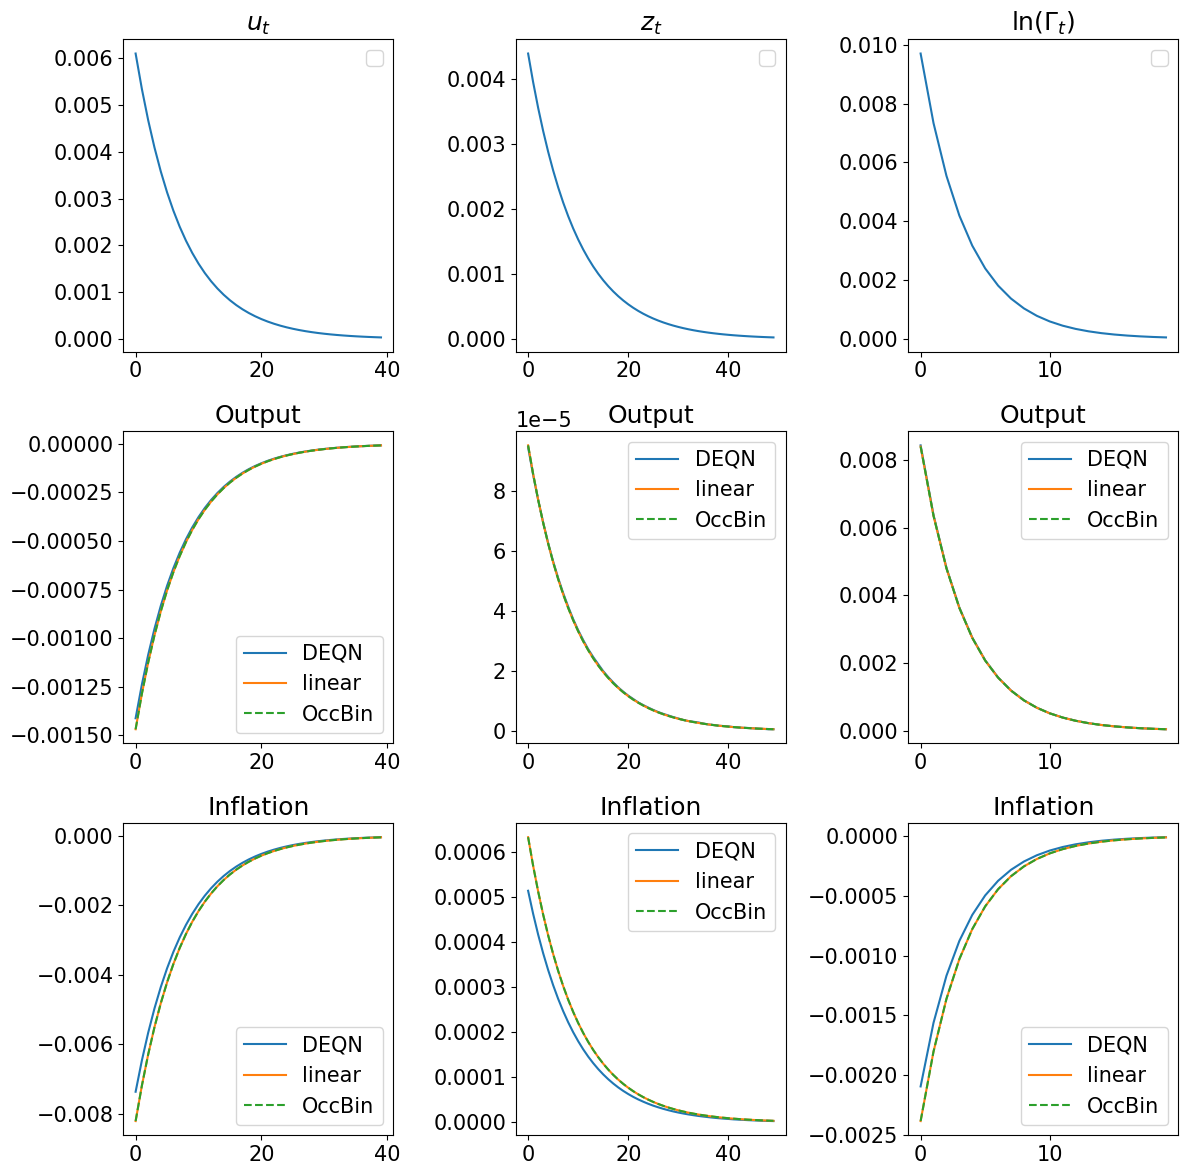

In [17]:
model.compute_IRF((0.0061, 0.0044, 0.0097), 150)
model.plot_IRF(save_path='IRFs.png')

In [10]:
solve.simulate(model, 70, (0.0082, 0.0044, 0.0097), extra_nn=model.train["nn_phase0"])

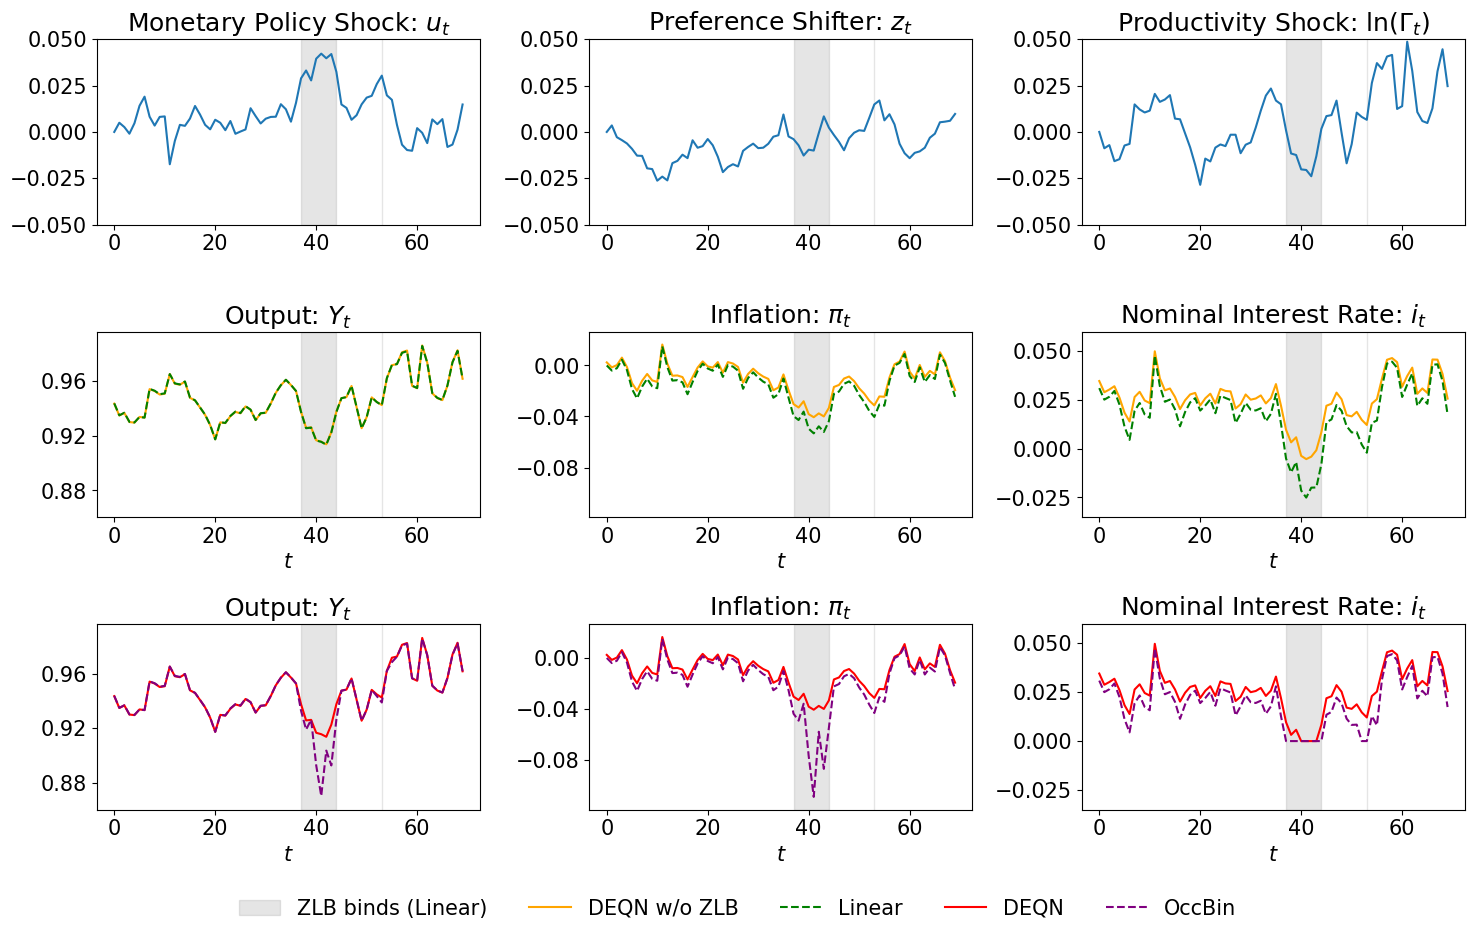

In [11]:
import matplotlib.ticker as mticker
plt.rcParams.update({'font.size': 15})

f, ax = plt.subplots(3,3, figsize=(15,10))

ax[0,0].plot(model.sim.states[:, 0])
ax[0,0].set_title(r'Monetary Policy Shock: $u_t$')

ax[0,1].plot(model.sim.states[:, 1])
ax[0,1].set_title(r'Preference Shifter: $z_t$')

ax[0,2].plot(model.sim.states[:, 2])
ax[0,2].set_title(r'Productivity Shock: $\ln(\Gamma_t)$')

for i in range(3):
    ax[0,i].set_ylim([-0.05, 0.05])

ax[1,0].plot(model.sim.Y_extra, label='DEQN w/o ZLB', color='orange')
ax[1,0].plot(model.sim.Y_lin, label='Linear', ls = '--', color='green')

ax[1,1].plot(model.sim.pi_extra, color='orange') #, label='DEQN w/o ZLB')
ax[1,1].plot(model.sim.pi_lin, ls='--', color='green') #, label='Linear', ls = '--')

ax[1,2].plot(model.sim.i_extra, color='orange') #, label='DEQN w/o ZLB')
ax[1,2].plot(model.sim.i_lin, ls='--', color='green') # label='Linear', ls = '--')

ax[2,0].plot(model.sim.Y, label='DEQN', color='red')
ax[2,0].plot(model.sim.Y_OccBin, label='OccBin', ls='--', color='purple')

ax[2,1].plot(model.sim.pi, color='red') #, label='DEQN')
ax[2,1].plot(model.sim.pi_OccBin, ls='--', color='purple') #, label='OccBin', ls='--')

ax[2,2].plot(model.sim.i, color='red') #, label='DEQN')
ax[2,2].plot(model.sim.i_OccBin, ls='--', color='purple') # label='OccBin', ls='--')

#
Ys_ = jnp.stack([model.sim.Y, model.sim.Y_lin, model.sim.Y_extra, model.sim.Y_OccBin])
pis_ = jnp.stack([model.sim.pi, model.sim.pi_lin, model.sim.pi_extra, model.sim.pi_OccBin])
is_ = jnp.stack([model.sim.i, model.sim.i_lin, model.sim.i_extra, model.sim.i_OccBin])

for i in range(1,3):
    ax[i,0].set_ylim([Ys_.min()-0.01, Ys_.max()+0.01])
    ax[i,1].set_ylim([pis_.min()-0.01, pis_.max()+0.01])
    ax[i,2].set_ylim([is_.min()-0.01, is_.max()+0.01])

#
for i in range(3):
    for j in range(1,3):
        ax[j,i].set_xlabel('$t$')

        ax[j,0].set_title(r'Output: $Y_t$')
        ax[j,1].set_title(r'Inflation: $\pi_t$')
        ax[j,2].set_title(r'Nominal Interest Rate: $i_t$')

zlb_mask = model.sim.i_lin < 0

label_add = True
for i in range(3):
    for j in range(3):
        
        if label_add:
            ax[i,j].fill_between(range(len(zlb_mask)), 
                             ax[i,j].get_ylim()[0], ax[i,j].get_ylim()[1], 
                             where=zlb_mask, 
                             color='gray', alpha=0.2, label='ZLB binds (Linear)')
            label_add = False

        else:
            ax[i,j].fill_between(range(len(zlb_mask)), 
                        ax[i,j].get_ylim()[0], ax[i,j].get_ylim()[1], 
                        where=zlb_mask, 
                        color='gray', alpha=0.2)

for i in range(3):
    for j in range(3):
        ax[i,j].yaxis.set_major_locator(mticker.MaxNLocator(nbins=4)) # nbins=4 giver præcis 5 ticks

# 1. Kør tight_layout FØRST, men lad 10% (0.1) være fri i bunden
f.tight_layout(rect=[0, 0.1, 1, 1])

# 2. Placer nu legenden i det frie område
f.legend(loc='lower center', 
         bbox_to_anchor=(0.5, 0.05), # 0.02 er lige over bunden i det tomme felt
         ncol=5,          
         frameon=False)

In [12]:
f.savefig('Simulation_Example.png')

# ERGODIC DISTRIBUTION

In [29]:
import jax
from neural_nets import eval_nn
import linear

In [30]:
key = jax.random.key(42)

N = 100_000

states = aux.draw_states_directly(key, model.par, jnp.float32, N, sigma_quad["sigma_eps_u"], sigma_quad["sigma_eps_z"], sigma_quad["sigma_eps_Gamma"])

states = states[None, :, :]

linear.simulate_linear(model, sigma_quad, 1, N, known_states=states)

In [31]:
Y, pi = eval_nn(model.par, model.train, model.linear, model.nn, states[0], N)

Y_extra, pi_extra = eval_nn(model.par, model.train, model.linear, model.train["nn_phase0"], states[0], N)

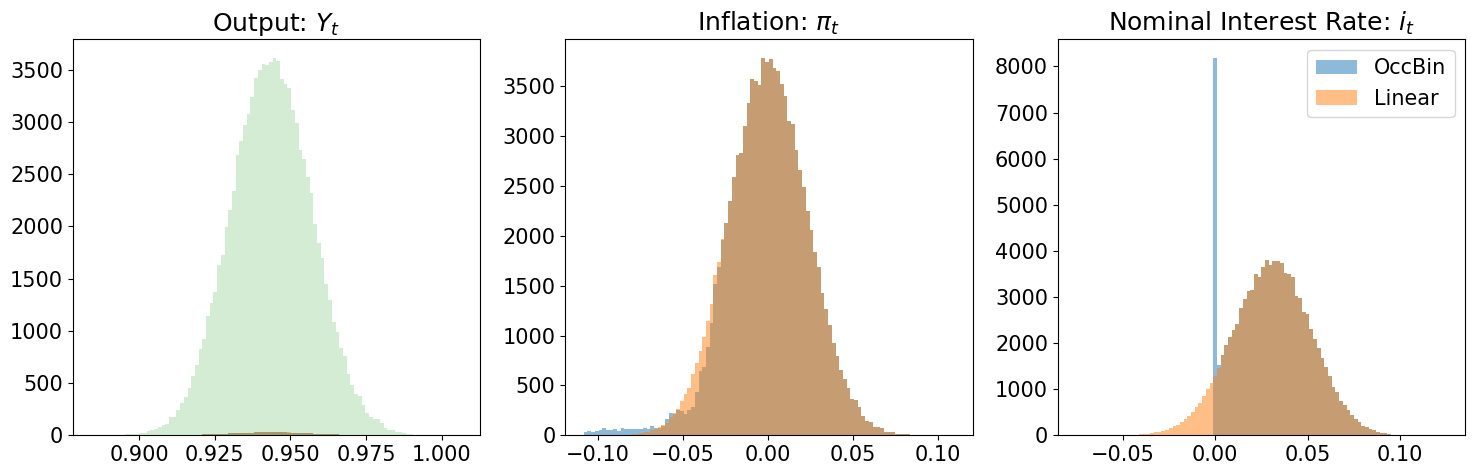

In [ ]:
# maximum observations
data_max = max(model.sim.Y_OccBin.max(), model.sim.Y_lin.max())
sh_bins = np.linspace(model.sim.Y_lin.min(), data_max, 101)

f, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].hist(model.sim.Y_OccBin, bins=sh_bins, alpha=0.5, label='OccBin', density=True)
ax[0].hist(model.sim.Y_lin, bins=sh_bins, alpha=0.5, label='Linear', density=True)
ax[0].set_title(r'Output: $Y_t$')

data_max = max(model.sim.pi_OccBin.max(), model.sim.pi_lin.max())
sh_bins = np.linspace(model.sim.pi_lin.min(), data_max, 101)

ax[1].hist(model.sim.pi_OccBin, bins=sh_bins, alpha=0.5, label='OccBin')
ax[1].hist(model.sim.pi_lin, bins=sh_bins, alpha=0.5, label='Linear')
ax[1].set_title(r'Inflation: $\pi_t$')

data_max = max(model.sim.i_OccBin.max(), model.sim.i_lin.max())
sh_bins = np.linspace(model.sim.i_lin.min(), data_max, 101)

ax[2].hist(model.sim.i_OccBin, bins=sh_bins, alpha=0.5, label='OccBin')
ax[2].hist(model.sim.i_lin, bins=sh_bins, alpha=0.5, label='Linear')
ax[2].set_title(r'Nominal Interest Rate: $i_t$')

ax[2].legend()

f.tight_layout()

#f.savefig('Ergodic_distribution_lin_OccBin.png')

In [37]:
import pickle

with open('info_train.pkl', 'wb') as f:
    pickle.dump(model.info, f)